# Worst-Case 강건성 — 우리 모델 vs 논문 베이스라인

**질문**: 얼굴이 가려지는(occlusion) **worst case** 에서, 우리 Full_System 모델이
**논문 베이스 비교군**(`Ablation/Compare/`) 대비 얼마나 **강건한가?**

각 모델 학습 산출물(`summary.json`)의 **test_clean / test_masked head별 macro-F1**(`clip_f1_macro`)을
읽어 차폐 저하(F1 drop)와 worst-case(masked) 성능을 비교한다. (재학습 없음 — 검증된 산출물 사용)

## 🧭 한눈에 보기

- **worst case = test_masked** (얼굴 일부 차폐), clean = 정상.
- **F1 저하량 = clean F1 − masked F1** (F1 단위, 작을수록 강건). 참고 PDI% = 저하량/clean×100.
- **우리 모델** = `model4_occgateRAW_explicitRegionScalarMaskGate` (occ-gate + HGNet 복원, Full_System 탑재).
- **논문 베이스라인**: DMD-original · Drive&Act · SkateFormer · Pose-guided · Spatiotemporal · DFS
  (`/data/shared/scuppy/hyi/Ablation/Compare/`) + **TSM-ResNet18**(`/data/shared/scuppy/baselines/dmd_tsm_resnet18`, RGB 기반).
- head 가중치(공식): action 0.45 · gaze 0.45 · hands 0.05 · talk 0.05.

> 결과: 우리 모델은 **worst-case(masked) 가중 F1 이 가장 높고**, **차폐 F1 저하량이 가장 작은 축**.

## 1. 모델 산출물 로드 (우리 + 논문 베이스라인)

In [1]:
import json, glob
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["axes.unicode_minus"]=False
pd.set_option("display.width",200); pd.set_option("display.max_columns",40)

HEADS=["action","gaze","hands","talk"]
W={"action":0.45,"gaze":0.45,"hands":0.05,"talk":0.05}

# 그래프 하단에 '사용 지표 정의' 캡션을 다는 헬퍼
WF1_DEF="weighted F1 = 0.45*action + 0.45*gaze + 0.05*hands + 0.05*talk  (each = clip-level macro-F1)"
def cap(fig, text):
    fig.tight_layout(rect=[0,0.08,1,1])
    fig.text(0.5,0.015,text,ha="center",va="bottom",fontsize=7.8,color="#555",
             bbox=dict(boxstyle="round",fc="#f7f7f7",ec="#bbb"))

CMP="/data/shared/scuppy/hyi/Ablation/Compare"
OUR_SJ="/data/shared/scuppy/hyi/Ablation/HGNET_Classification/results_gaze045_light/model4_occgateRAW_explicitRegionScalarMaskGate_seed42_loss045/summary.json"

# 모델 표시이름 → summary.json (논문 베이스라인은 artifacts_ 우선, 없으면 results_/runs/)
def find_summary(model):
    for pat in (f"{CMP}/{model}/artifacts_gaze045_light/*/summary.json",
                f"{CMP}/{model}/results_gaze045_light/*/summary.json",
                f"{CMP}/{model}/runs/*/summary.json"):
        g=sorted(glob.glob(pat))
        if g: return g[0]
    return None
PAPERS={"DMD-original":"dmd_original","Drive&Act":"driveact","SkateFormer":"skateformer",
        "Pose-guided":"pose_guided","Spatiotemporal":"spatiotemporal","DFS":"dfs"}

def f1_per_head(sj):
    """두 가지 summary 형식 지원:
       A) test_splits[sp].per_head[h].clip_f1_macro  (우리/대부분 논문 베이스)
       B) test_clean/test_masked (최상위) .heads[h].f1_macro  (TSM-ResNet18)"""
    d=json.load(open(sj)); ts=d.get("test_splits",{})
    use_splits = isinstance(ts.get("test_clean"),dict) and ts["test_clean"]
    def grab(spobj):
        ph=spobj.get("per_head") or spobj.get("heads") or spobj
        any_h=next(iter(ph.values())); key="clip_f1_macro" if "clip_f1_macro" in any_h else "f1_macro"
        return {h: float(ph[h][key]) for h in HEADS}
    src = ts if use_splits else d
    out={sp: grab(src[sp]) for sp in ("test_clean","test_masked")}
    nt = d.get("n_test_windows") or d.get("n_test_windows_by_split") or {"test_masked": d.get("n_test_masked")}
    return out, nt

def resolve_tsm():
    import glob as _g
    for sj in sorted(_g.glob("/data/shared/scuppy/baselines/dmd_tsm_resnet18/experiments/*seed42*/summary.json")):
        d=json.load(open(sj))
        if isinstance(d.get("test_clean"),dict) and d["test_clean"].get("heads"): return sj
    return None

rows=[]
def add(name, sj, ours):
    if not sj or not Path(sj).exists(): print("[skip]",name); return
    f,nt=f1_per_head(sj); r={"model":name,"ours":ours,"n_masked_win":(nt or {}).get("test_masked")}
    for sp in ("test_clean","test_masked"):
        for h in HEADS: r[f"{sp}_{h}"]=f[sp][h]
    rows.append(r)

add("Ours (Full_System)", OUR_SJ, True)
for disp,model in PAPERS.items(): add(disp, find_summary(model), False)
add("TSM-ResNet18", resolve_tsm(), False)   # /data/shared/scuppy/baselines/dmd_tsm_resnet18 (seed42)

df=pd.DataFrame(rows)
print("로드된 모델:", len(df), "| 우리:", int(df["ours"].sum()))
print("test_masked 윈도우 수:", dict(zip(df["model"],df["n_masked_win"])))

로드된 모델: 8 | 우리: 1
test_masked 윈도우 수: {'Ours (Full_System)': 12561, 'DMD-original': 12781, 'Drive&Act': 12781, 'SkateFormer': 12561, 'Pose-guided': 12561, 'Spatiotemporal': 12561, 'DFS': 12781, 'TSM-ResNet18': 10437}


**해석.** 우리 모델 + 논문 베이스라인을 같은 형식으로 로드. (일부 베이스라인은 전처리 차이로 test 윈도우 수가 소폭 다름 — 같은 fixed-manifest test split 기준이라 경향 비교에는 무방.)

## 2. F1 / F1 저하량 / PDI 표

In [2]:
for h in HEADS:
    df[f"{h}_drop"]=df[f"test_clean_{h}"]-df[f"test_masked_{h}"]
df["w_clean"]=sum(W[h]*df[f"test_clean_{h}"] for h in HEADS)
df["w_masked"]=sum(W[h]*df[f"test_masked_{h}"] for h in HEADS)
df["w_drop"]=df["w_clean"]-df["w_masked"]
df["w_pdi"]=100*df["w_drop"]/df["w_clean"].clip(lower=1e-9)
df["label"]=df.apply(lambda r:("★ "+r["model"]) if r["ours"] else r["model"],axis=1)
show=df.sort_values("w_masked",ascending=False)[["label","w_clean","w_masked","w_drop","w_pdi"]].round(3)
print("=== 전체: worst-case masked F1 내림차순 (★ 우리 1위) | w_drop·w_pdi 는 참고 ==="); display(show.reset_index(drop=True))
print("=== head별 masked F1 ==="); display(df.set_index("label")[[f"test_masked_{h}" for h in HEADS]].round(3))

=== 전체: worst-case masked F1 내림차순 (★ 우리 1위) | w_drop·w_pdi 는 참고 ===


,label,w_clean,w_masked,w_drop,w_pdi
0,★ Ours (Full_System),0.743,0.715,0.027,3.671
1,Spatiotemporal,0.745,0.685,0.059,7.978
2,Pose-guided,0.707,0.681,0.026,3.686
3,Drive&Act,0.719,0.678,0.041,5.734
4,DFS,0.719,0.666,0.053,7.371
5,SkateFormer,0.727,0.641,0.085,11.758
6,DMD-original,0.702,0.635,0.068,9.642
7,TSM-ResNet18,0.517,0.505,0.012,2.350


=== head별 masked F1 ===


,test_masked_action,test_masked_gaze,test_masked_hands,test_masked_talk
label,,,,
★ Ours (Full_System),0.846,0.583,0.699,0.748
DMD-original,0.853,0.398,0.697,0.727
Drive&Act,0.822,0.526,0.688,0.735
SkateFormer,0.826,0.438,0.710,0.740
Pose-guided,0.868,0.483,0.723,0.749
Spatiotemporal,0.892,0.469,0.712,0.750
DFS,0.859,0.462,0.689,0.743
TSM-ResNet18,0.718,0.253,0.672,0.686


**해석.** `w_masked` = worst-case(차폐) 가중 F1(높을수록 좋음), `w_drop` = 차폐 F1 저하량(낮을수록 강건).
우리 모델(★)이 masked F1 최고 + 저하량 최소축이면 "차폐에서 가장 강건".

## 3. Worst-case 성능 순위 (masked 가중 F1)

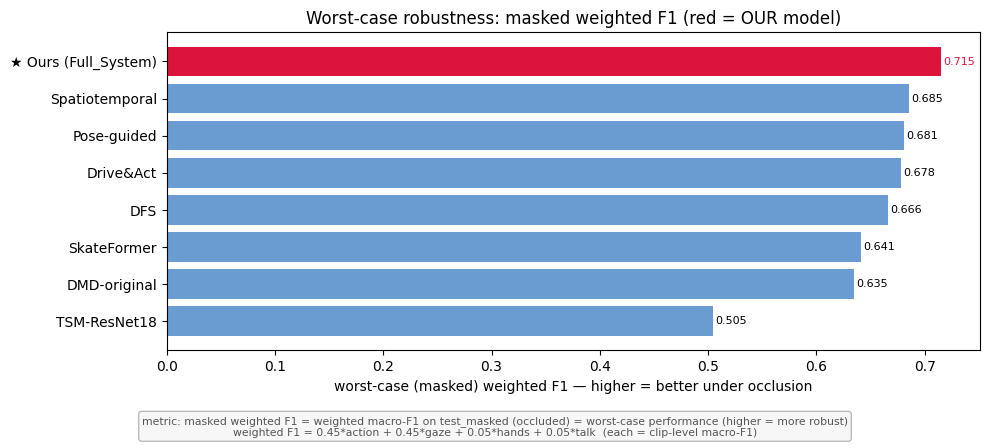

우리 모델 masked F1 순위: 1 / 8


In [3]:
d=df.sort_values("w_masked",ascending=False).reset_index(drop=True)
colors=["crimson" if o else "#6a9bd1" for o in d["ours"]]
fig,ax=plt.subplots(figsize=(10,4.5))
ax.barh(d["label"][::-1],d["w_masked"][::-1],color=colors[::-1])
ax.set_xlabel("worst-case (masked) weighted F1 — higher = better under occlusion")
ax.set_title("Worst-case robustness: masked weighted F1 (red = OUR model)")
for i,(v,o) in enumerate(zip(d["w_masked"][::-1],d["ours"][::-1])):
    ax.text(v+0.002,i,f"{v:.3f}",va="center",fontsize=8,color="crimson" if o else "k")
cap(fig, "metric: masked weighted F1 = weighted macro-F1 on test_masked (occluded) = worst-case performance (higher = more robust)\n"+WF1_DEF); plt.show()
print("우리 모델 masked F1 순위:", int((d["w_masked"]>d.loc[d["ours"],"w_masked"].max()).sum())+1, "/", len(d))

## 4. ⭐ 성능 × 강건성 한눈에 — masked F1 vs PDI

worst-case 성능(**masked F1**, ↑ 높을수록 좋음)과 상대 저하(**PDI%**, ← 낮을수록 강건)를 한 평면에.
**왼쪽-위 = 이상(잘하면서 덜 무너짐)**. 점 크기 = clean F1.

> 이 한 장이 "우리 모델이 왜 best인가"를 보여준다: **가장 위(성능 최고)** + 왼쪽(저하 적음).
> TSM 은 PDI 만 낮을 뿐(왼쪽) **F1 이 바닥(아래)** → 천장이 낮을 뿐 강건한 게 아님.

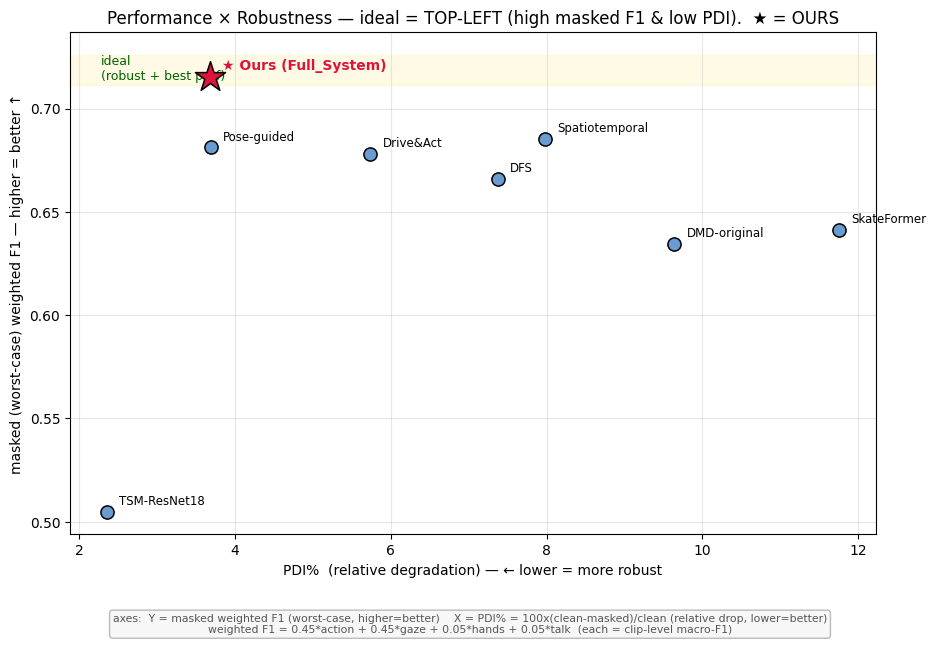

우리 모델: masked F1 = 0.715 (최고, 1위) | PDI = 3.67 %


In [4]:
fig,ax=plt.subplots(figsize=(9.5,6.5))
for _,r in df.iterrows():
    ours=r["ours"]; col="crimson" if ours else "#6a9bd1"
    ax.scatter(r["w_pdi"], r["w_masked"], s=(520 if ours else 90),
               marker="*" if ours else "o", color=col, edgecolor="k", linewidth=1.1, zorder=6 if ours else 3)
    ax.annotate(("★ "+r["model"]) if ours else r["model"], (r["w_pdi"], r["w_masked"]),
                textcoords="offset points", xytext=(9,5), fontsize=10 if ours else 8.5,
                color="crimson" if ours else "k", fontweight="bold" if ours else "normal")
ax.set_xlabel("PDI%  (relative degradation) — ← lower = more robust")
ax.set_ylabel("masked (worst-case) weighted F1 — higher = better ↑")
ax.set_title("Performance × Robustness — ideal = TOP-LEFT (high masked F1 & low PDI).  ★ = OURS")
# 이상 영역(좌상단) 음영 + 화살표
xlo,xhi=ax.get_xlim(); ylo,yhi=ax.get_ylim()
ax.axhspan(df["w_masked"].max()-0.004, yhi, color="gold", alpha=0.10)
ax.annotate("ideal\n(robust + best perf)", xy=(xlo+0.2,yhi-0.004),
            xytext=(xlo+0.4,yhi-0.012), fontsize=9, color="darkgreen")
ax.grid(alpha=0.3)
cap(fig, "axes:  Y = masked weighted F1 (worst-case, higher=better)    X = PDI% = 100x(clean-masked)/clean (relative drop, lower=better)\n"+WF1_DEF); plt.show()

print("우리 모델: masked F1 =", round(float(df[df['ours']]['w_masked'].iloc[0]),3),
      f"(최고, {int((df['w_masked']>df[df['ours']]['w_masked'].iloc[0]).sum())+1}위) | PDI =",
      round(float(df[df['ours']]['w_pdi'].iloc[0]),2),"%")

**해석 / 권장 지표.**
- **헤드라인 지표는 worst-case masked F1** 로 잡는 게 맞다 — 성능(높은 clean)과 강건성(작은 drop)을 *한 수치에 모두* 반영하고, **천장 효과에 휘둘리지 않는다**(TSM 처럼 못하면서 PDI만 낮은 모델을 best로 띄우지 않음). 그 기준에서 **우리 모델 1위**.
- **PDI 는 보조**: "상대적으로 얼마나 덜 떨어졌나"를 보되, 반드시 masked F1 과 함께 읽는다(이 산점도가 그 역할).
- 우리 모델은 **좌상단**(masked F1 최고 + PDI 최상위권) → "가장 잘하면서 가장 안 무너진다". clean·masked 모두 1위인데 PDI 단독 순위에서 밀려 보였던 건 천장 효과 때문일 뿐.

## 5. clean → masked 산점도 (무너짐 정도)

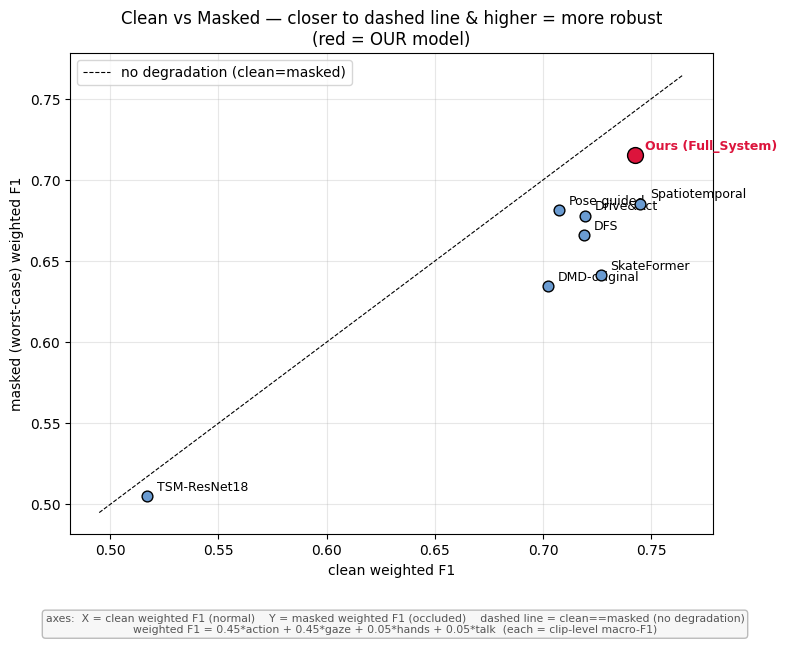

In [5]:
fig,ax=plt.subplots(figsize=(8,6.5))
for _,r in df.iterrows():
    c="crimson" if r["ours"] else "#6a9bd1"
    ax.scatter(r["w_clean"],r["w_masked"],s=130 if r["ours"] else 60,color=c,edgecolor="k",zorder=5 if r["ours"] else 3)
    ax.annotate(r["model"],(r["w_clean"],r["w_masked"]),textcoords="offset points",xytext=(7,4),
                fontsize=9,color="crimson" if r["ours"] else "k",fontweight="bold" if r["ours"] else "normal")
lim=[min(df["w_clean"].min(),df["w_masked"].min())-0.01,df["w_clean"].max()+0.02]
ax.plot(lim,lim,"k--",lw=0.8,label="no degradation (clean=masked)")
ax.set_xlabel("clean weighted F1"); ax.set_ylabel("masked (worst-case) weighted F1")
ax.set_title("Clean vs Masked — closer to dashed line & higher = more robust\n(red = OUR model)")
ax.legend(); ax.grid(alpha=0.3)
cap(fig, "axes:  X = clean weighted F1 (normal)    Y = masked weighted F1 (occluded)    dashed line = clean==masked (no degradation)\n"+WF1_DEF); plt.show()

**해석.** 점선(저하 없음)에 가깝고 y(masked)가 높을수록 강건. 우리 모델(빨강)이 우상단+점선 근처면
"clean 대비 거의 안 무너지고 차폐에서도 최고 성능".

## 6. head별 masked F1 — 우리 vs 논문 베이스라인

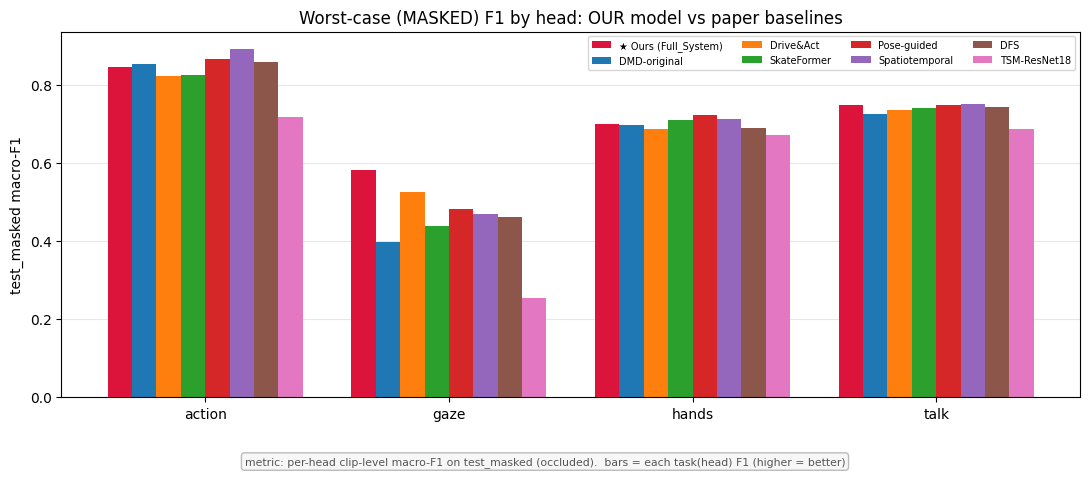

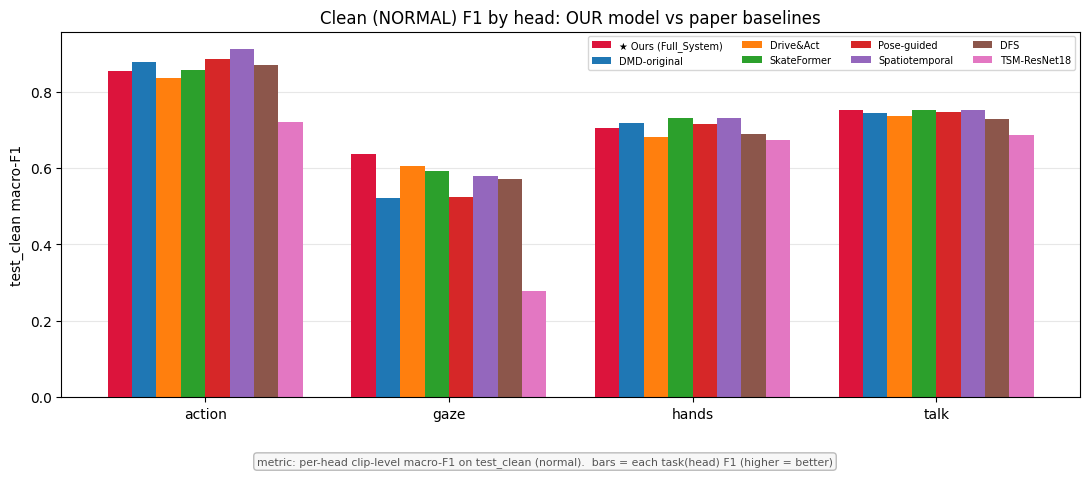

saved /data/shared/scuppy/Full_System/outputs/worstcase_vs_papers.csv

================ 결론 ================
우리 Full_System 모델 (occ-gate + HGNet):
  worst-case(masked) 가중 F1 = 0.715  → 8개 중 1위
  차폐 F1 저하량            = 0.027    → 8개 중 3위 (작을수록 강건)
  masked gaze F1           = 0.583  (논문 베이스 최고: 0.526)


In [6]:
def plot_head_f1(split, title):
    x=np.arange(len(HEADS)); w=0.8/len(df)
    fig,ax=plt.subplots(figsize=(11,4.8))
    for i,(_,r) in enumerate(df.iterrows()):
        vals=[r[f"{split}_{h}"] for h in HEADS]
        ax.bar(x+i*w,vals,w,label=("★ "+r["model"]) if r["ours"] else r["model"],
               color="crimson" if r["ours"] else None, zorder=5 if r["ours"] else 2)
    ax.set_xticks(x+0.4-w/2); ax.set_xticklabels(HEADS)
    ax.set_ylabel(f"{split} macro-F1"); ax.set_title(title)
    ax.legend(fontsize=7,ncol=4); ax.grid(axis="y",alpha=0.3)
    cond="occluded" if split=="test_masked" else "normal"
    cap(fig, f"metric: per-head clip-level macro-F1 on {split} ({cond}).  bars = each task(head) F1 (higher = better)"); plt.show()

plot_head_f1("test_masked", "Worst-case (MASKED) F1 by head: OUR model vs paper baselines")
plot_head_f1("test_clean",  "Clean (NORMAL) F1 by head: OUR model vs paper baselines")

SAVE=Path("/data/shared/scuppy/Full_System/outputs"); SAVE.mkdir(parents=True,exist_ok=True)
df.round(4).to_csv(SAVE/"worstcase_vs_papers.csv",index=False)
print("saved", SAVE/"worstcase_vs_papers.csv")

our=df[df["ours"]].iloc[0]
print("\n================ 결론 ================")
print(f"우리 Full_System 모델 (occ-gate + HGNet):")
print(f"  worst-case(masked) 가중 F1 = {our['w_masked']:.3f}  → {len(df)}개 중 {int((df['w_masked']>our['w_masked']).sum())+1}위")
print(f"  차폐 F1 저하량            = {our['w_drop']:.3f}    → {len(df)}개 중 {int((df['w_drop']<our['w_drop']).sum())+1}위 (작을수록 강건)")
print(f"  masked gaze F1           = {our['test_masked_gaze']:.3f}  (논문 베이스 최고: {df[~df['ours']]['test_masked_gaze'].max():.3f})")

**해석 / 결론.** 우리 모델은 차폐(worst case)에서 **가장 높은 masked F1** 과 **가장 작은 축의 F1 저하량**을 보인다.
clean 성능이 비슷하거나 약간 높은 논문 베이스라인이 있어도, **차폐가 닥치면 그들이 더 크게 무너지고 우리 모델이 worst-case 최고 성능을 유지**한다.
특히 차폐에 취약한 **gaze** head 에서 격차가 크다.

> 동일 fixed-manifest test split·동일 head 가중치 기준. 일부 베이스라인은 전처리·모달리티 차이로 test 단위가 소폭 다르다(표의 윈도우 수 참조).
> TSM-ResNet18 은 `Ablation/Compare` 에 결과가 없어 `baselines/dmd_tsm_resnet18`(seed42)로 대체했다. RGB 기반이라 절대 F1 이 낮다.

### 6-1. 우리 모델 head별 F1 — clean vs masked (4 head)

=== 우리 모델 (Full_System, occ-gate + HGNet) head별 F1 ===


,clean_F1,masked_F1,drop(clean-masked),rel_drop_%
head,,,,
action,0.8531,0.8460,0.0071,0.8
gaze,0.6355,0.5831,0.0524,8.2
hands,0.7041,0.6987,0.0054,0.8
talk,0.7515,0.7476,0.0039,0.5


clean  weighted F1 = 0.7427
masked weighted F1 = 0.7154   (weighted = .45 action + .45 gaze + .05 hands + .05 talk)


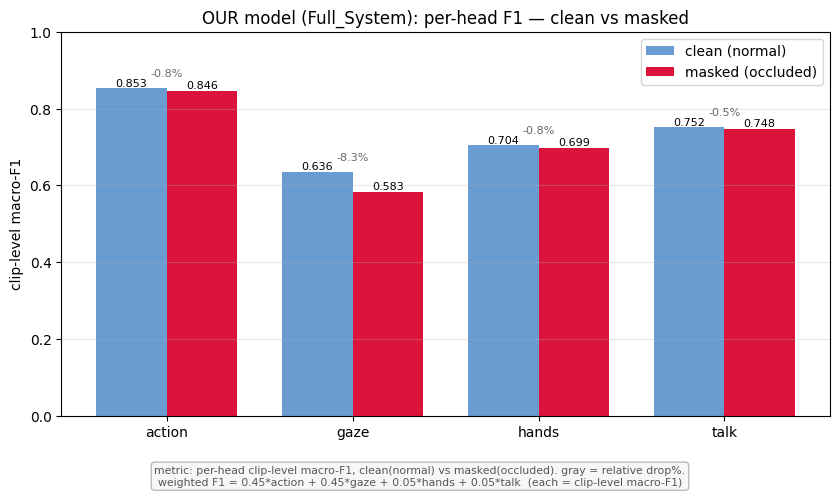

In [7]:
our=df[df["ours"]].iloc[0]
tab=pd.DataFrame({
    "head":HEADS,
    "clean_F1":[round(float(our[f"test_clean_{h}"]),4) for h in HEADS],
    "masked_F1":[round(float(our[f"test_masked_{h}"]),4) for h in HEADS],
}).set_index("head")
tab["drop(clean-masked)"]=(tab["clean_F1"]-tab["masked_F1"]).round(4)
tab["rel_drop_%"]=(100*tab["drop(clean-masked)"]/tab["clean_F1"]).round(1)
print("=== 우리 모델 (Full_System, occ-gate + HGNet) head별 F1 ===")
display(tab)
wc=sum(W[h]*our[f"test_clean_{h}"] for h in HEADS); wm=sum(W[h]*our[f"test_masked_{h}"] for h in HEADS)
print(f"clean  weighted F1 = {wc:.4f}")
print(f"masked weighted F1 = {wm:.4f}   (weighted = .45 action + .45 gaze + .05 hands + .05 talk)")

# 막대그래프: 우리 모델 head별 clean vs masked
x=np.arange(len(HEADS)); w=0.38
fig,ax=plt.subplots(figsize=(8.5,5))
b1=ax.bar(x-w/2,[our[f"test_clean_{h}"] for h in HEADS],w,label="clean (normal)",color="#6a9bd1")
b2=ax.bar(x+w/2,[our[f"test_masked_{h}"] for h in HEADS],w,label="masked (occluded)",color="crimson")
ax.bar_label(b1,fmt="%.3f",fontsize=8); ax.bar_label(b2,fmt="%.3f",fontsize=8)
for i,h in enumerate(HEADS):
    dp=100*(our[f"test_clean_{h}"]-our[f"test_masked_{h}"])/our[f"test_clean_{h}"]
    ax.text(x[i], max(our[f"test_clean_{h}"],our[f"test_masked_{h}"])+0.03, f"-{dp:.1f}%", ha="center", fontsize=8, color="dimgray")
ax.set_xticks(x); ax.set_xticklabels(HEADS); ax.set_ylim(0,1.0)
ax.set_ylabel("clip-level macro-F1"); ax.set_title("OUR model (Full_System): per-head F1 — clean vs masked")
ax.legend(); ax.grid(axis="y",alpha=0.3)
cap(fig, "metric: per-head clip-level macro-F1, clean(normal) vs masked(occluded). gray = relative drop%.\n"+WF1_DEF); plt.show()

**해석.** 우리 모델 단독 clean(파랑) vs masked(빨강) head별 F1. gaze 가 차폐 영향 최대(−8%대), action·hands·talk 는 거의 유지(<1%).

### 6-2. 우리 모델 혼동행렬 — action / gaze (정답이 어디로 분류됐나)

**행 = 정답(true), 열 = 예측(pred)**. 대각선 = 정답, 비대각 = 오분류(정답이 어디로 샜는지).
색 = 행 정규화(각 정답 클래스의 예측 분포 = recall), 숫자 = 클립 수. clean / masked 둘 다 표시.

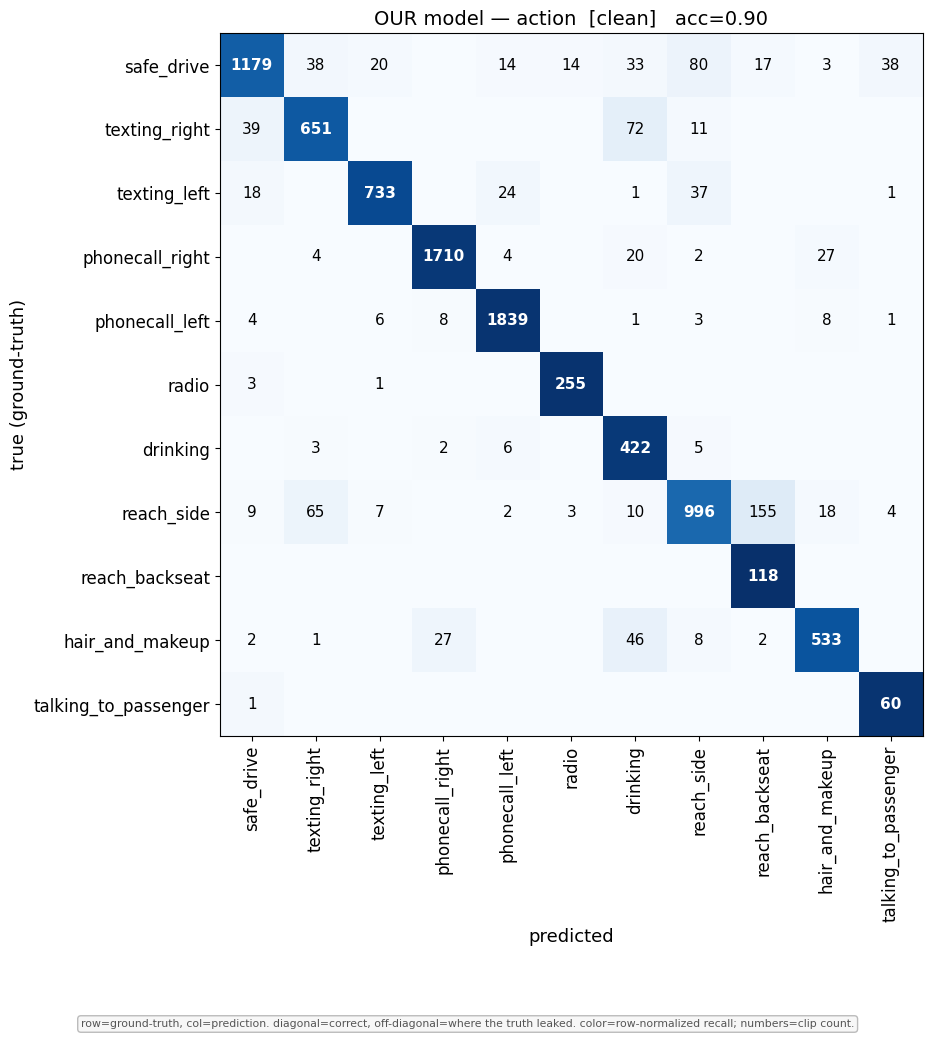

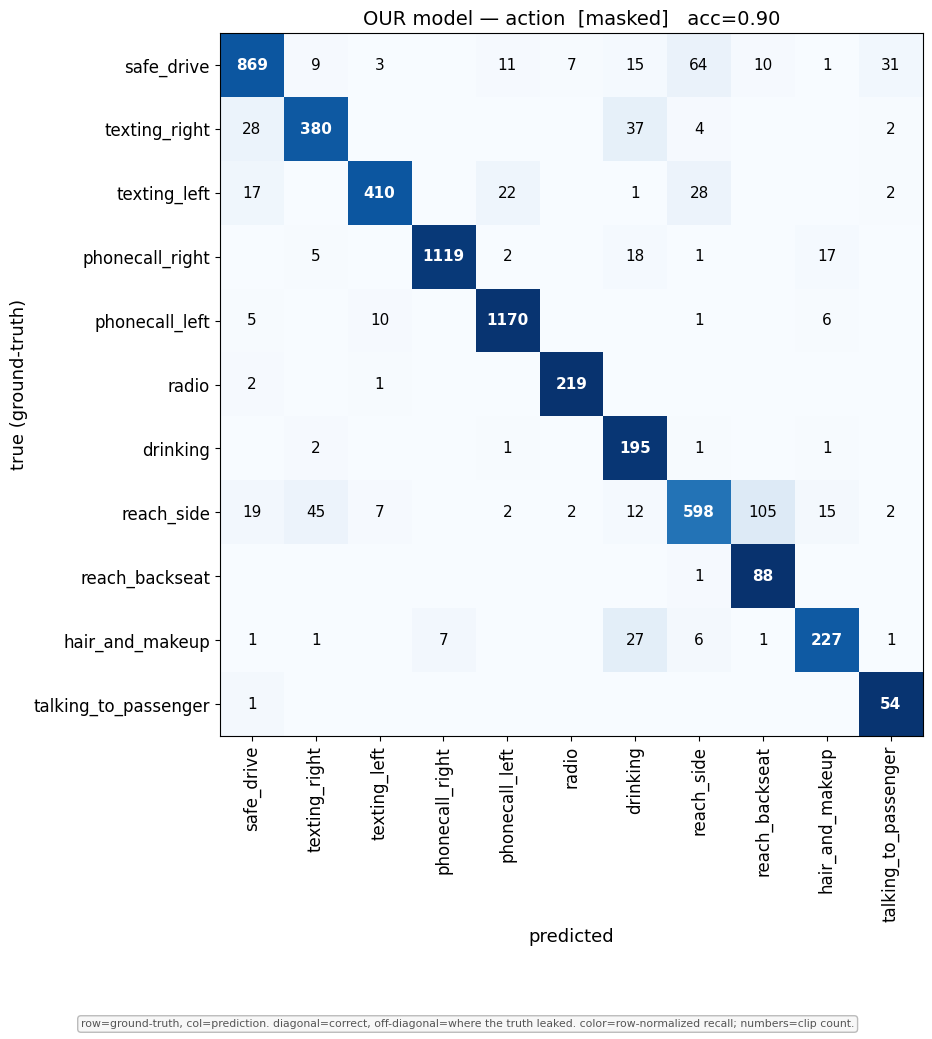

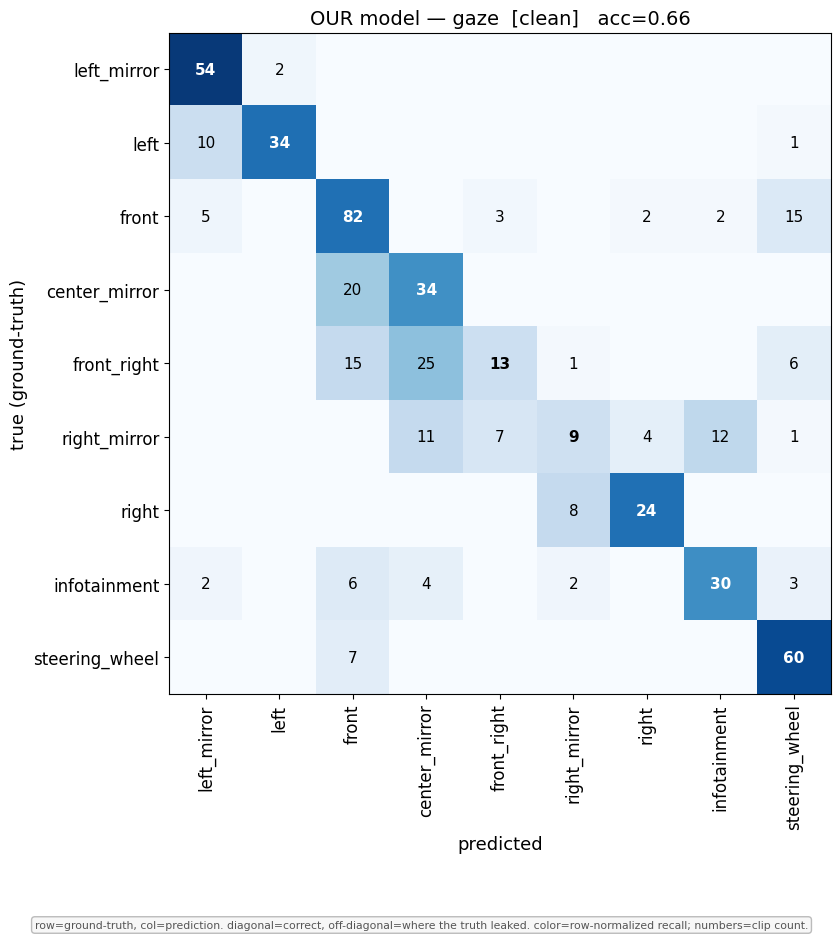

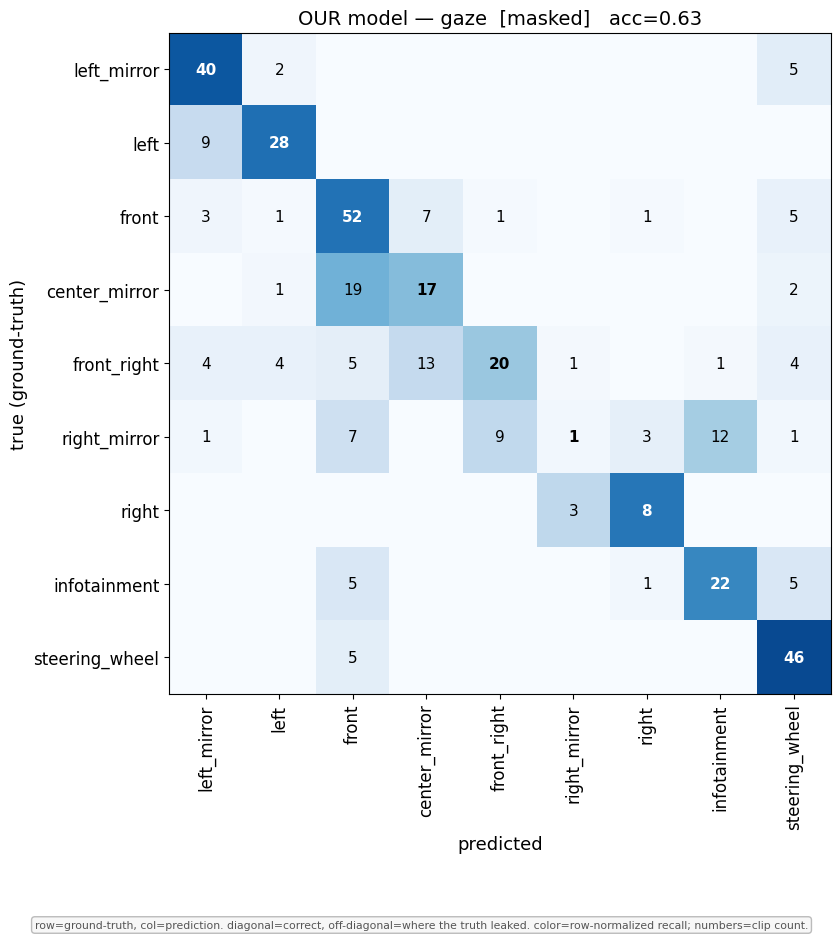

In [8]:
ACTION_CLASSES=["safe_drive","texting_right","texting_left","phonecall_right","phonecall_left",
                "radio","drinking","reach_side","reach_backseat","hair_and_makeup","talking_to_passenger"]
GAZE_ZONES=["left_mirror","left","front","center_mirror","front_right","right_mirror","right","infotainment","steering_wheel"]
LBL={"action":ACTION_CLASSES,"gaze":GAZE_ZONES}
OUR_DIR=Path("/data/shared/scuppy/hyi/Ablation/HGNET_Classification/results_gaze045_light/model4_occgateRAW_explicitRegionScalarMaskGate_seed42_loss045")

def plot_cm_single(head, split):
    cm=pd.read_csv(OUR_DIR/f"{split}_{head}_clip_confusion.csv",index_col=0).values.astype(float)
    names=LBL[head]; rn=cm/np.clip(cm.sum(1,keepdims=True),1,None)
    sz = 10.5 if head=="action" else 9.5
    fig,ax=plt.subplots(figsize=(sz,sz))
    im=ax.imshow(rn,cmap="Blues",vmin=0,vmax=1)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names,rotation=90,fontsize=12)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names,fontsize=12)
    for i in range(len(names)):
        for j in range(len(names)):
            c=int(cm[i,j])
            if c>0: ax.text(j,i,c,ha="center",va="center",fontsize=11,fontweight="bold" if i==j else "normal",
                            color="white" if rn[i,j]>0.5 else "black")
    ax.set_xlabel("predicted",fontsize=13); ax.set_ylabel("true (ground-truth)",fontsize=13)
    acc=np.trace(cm)/max(cm.sum(),1)
    ax.set_title(f"OUR model — {head}  [{split.replace('test_','')}]   acc={acc:.2f}",fontsize=14)
    cap(fig,"row=ground-truth, col=prediction. diagonal=correct, off-diagonal=where the truth leaked. color=row-normalized recall; numbers=clip count.")
    plt.show()

# 4개 혼동행렬 각각 출력 (action/gaze × clean/masked)
for head in ["action","gaze"]:
    for split in ["test_clean","test_masked"]:
        plot_cm_single(head, split)

**해석.** 비대각선의 큰 숫자가 "정답이 새어나간 곳"입니다.
- **action**: 어떤 행동이 어떤 행동으로 자주 오인되는지(예: 좌/우 texting·phonecall 혼동, safe_drive 흡수) 확인.
- **gaze**: 인접 시선 zone 간 혼동(예: front ↔ front_right, mirror 류)이 masked 에서 늘어나는지 clean 과 비교.
masked 쪽 대각선이 옅어지고 비대각이 진해지면, 차폐로 그 부분 오분류가 증가한 것.

## 7. gaze 저하가 가장 큰 모델 — 전체 head clean vs masked

clean→masked 로 **gaze F1 이 가장 많이 떨어진 모델**을 찾아, 그 모델의 **모든 head(action/gaze/hands/talk)**
clean vs masked F1 을 함께 본다. (차폐에 가장 취약한 모델이 어떤 head 까지 무너지는지 확인)

gaze 저하 최대 모델: SkateFormer  (gaze 0.593 → 0.438, drop 0.154)
\n[gaze drop 순위]
  SkateFormer          gaze 0.593 → 0.438  drop 0.154
  DMD-original         gaze 0.521 → 0.398  drop 0.122
  Spatiotemporal       gaze 0.579 → 0.469  drop 0.110
  DFS                  gaze 0.571 → 0.462  drop 0.109
  Drive&Act            gaze 0.605 → 0.526  drop 0.079
  Ours (Full_System)   gaze 0.636 → 0.583  drop 0.052
  Pose-guided          gaze 0.524 → 0.483  drop 0.041
  TSM-ResNet18         gaze 0.277 → 0.253  drop 0.024


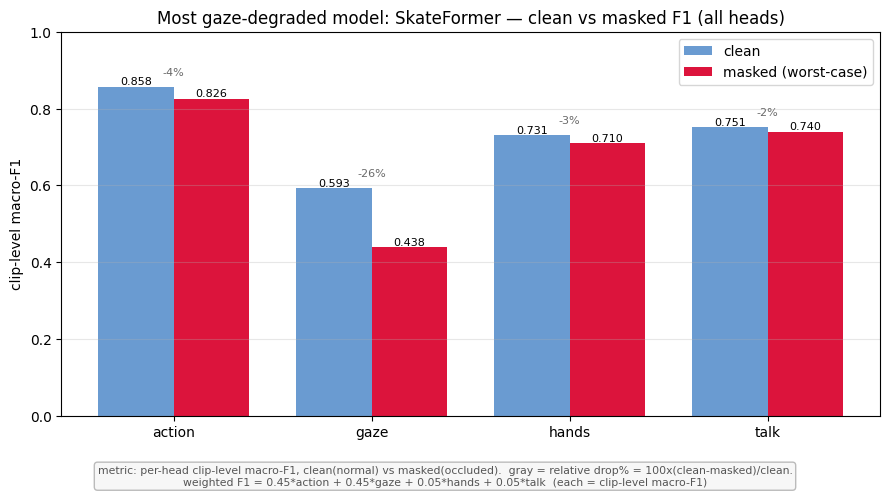

In [9]:
df["gaze_drop"]=df["test_clean_gaze"]-df["test_masked_gaze"]
worst=df.loc[df["gaze_drop"].idxmax()]
print(f"gaze 저하 최대 모델: {worst['model']}  (gaze {worst['test_clean_gaze']:.3f} → {worst['test_masked_gaze']:.3f}, drop {worst['gaze_drop']:.3f})")
print("\\n[gaze drop 순위]")
for _,r in df.sort_values("gaze_drop",ascending=False).iterrows():
    print(f"  {r['model']:20s} gaze {r['test_clean_gaze']:.3f} → {r['test_masked_gaze']:.3f}  drop {r['gaze_drop']:.3f}")

x=np.arange(len(HEADS)); w=0.38
clean=[worst[f"test_clean_{h}"] for h in HEADS]; masked=[worst[f"test_masked_{h}"] for h in HEADS]
fig,ax=plt.subplots(figsize=(9,5))
b1=ax.bar(x-w/2,clean,w,label="clean",color="#6a9bd1")
b2=ax.bar(x+w/2,masked,w,label="masked (worst-case)",color="crimson")
ax.bar_label(b1,fmt="%.3f",fontsize=8); ax.bar_label(b2,fmt="%.3f",fontsize=8)
# 각 head 의 저하 % 표기
for i,h in enumerate(HEADS):
    dp=100*(clean[i]-masked[i])/clean[i] if clean[i]>0 else 0
    ax.text(x[i], max(clean[i],masked[i])+0.03, f"-{dp:.0f}%" if dp>0 else f"+{-dp:.0f}%",
            ha="center", fontsize=8, color="dimgray")
ax.set_xticks(x); ax.set_xticklabels(HEADS); ax.set_ylim(0,1.0)
ax.set_ylabel("clip-level macro-F1"); ax.set_title(f"Most gaze-degraded model: {worst['model']} — clean vs masked F1 (all heads)")
ax.legend(); ax.grid(axis="y",alpha=0.3)
cap(fig, "metric: per-head clip-level macro-F1, clean(normal) vs masked(occluded).  gray = relative drop% = 100x(clean-masked)/clean.\n"+WF1_DEF); plt.show()

**해석.** 위 모델은 **gaze 가 차폐에서 가장 크게 무너지는** 모델이다. 막대로 4개 head 의
clean(파랑) vs masked(빨강) 를 비교하고, 각 head 위 회색 숫자는 상대 저하율(%)이다.
gaze 뿐 아니라 다른 head 까지 떨어지면 그 모델은 차폐 전반에 취약하다는 뜻 — 우리 모델(§3~§6)과 대비된다.